# 04. Aplicação Estratégica
## Das previsões à política pública

Este notebook responde as cinco perguntas de negócio do desafio:

1. **Quais fatores mais impactam a alfabetização?** (consolidação do notebook 03)
2. **Quais municípios apresentam maior risco educacional?**
3. **Quais regiões possuem padrões semelhantes?** (clustering)
4. **Como prever municípios que podem não atingir metas futuras?**
5. **Quais variáveis possuem maior influência nos modelos?** (notebook 03)

Insumos: previsões fora-da-amostra do modelo no teste de 2024, tabelas Gold da
Fase 2, metas municipais por ano e o diretório de municípios.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "..")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../images"); REP = Path("../reports")

pred = pd.read_parquet("../data/predicoes_teste_2024.parquet")
nomes = pd.read_parquet("../data/dim_municipios.parquet")
metas = pd.read_parquet("../data/metas_municipio_por_ano.parquet")
base = pd.read_parquet("../data/gold_base_ml_alunos.parquet")
print(f"{len(pred):,} previsões (teste 2024), {len(nomes):,} municípios no diretório")

1,852,788 previsões (teste 2024), 5,571 municípios no diretório


## Pergunta 2: Municípios com maior risco educacional

Risco municipal = média (ponderada pelo peso amostral) da probabilidade prevista
de **não** alfabetização entre os alunos de 2024. Como as previsões são
fora-da-amostra (o modelo nunca viu 2024), o ranking é um retrato honesto do que
o modelo anteciparia **antes** da avaliação. Filtro de robustez: municípios com
pelo menos 100 alunos avaliados.

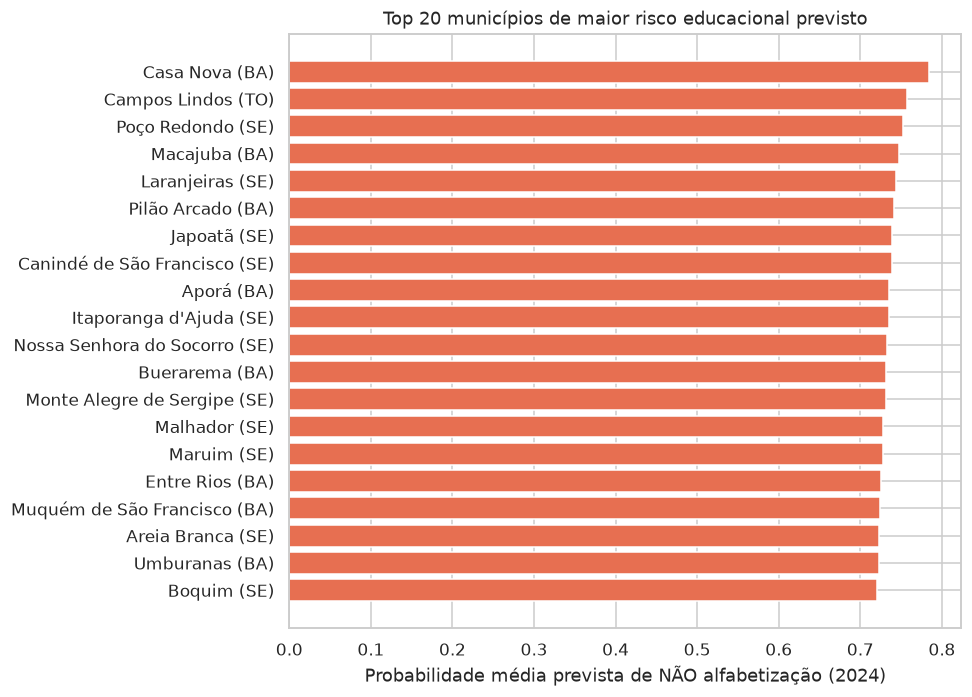

,nome,sigla_uf,alunos,risco_previsto,taxa_real_2024
1118,Casa Nova,BA,430,0.785,0.209
268,Campos Lindos,TO,148,0.758,0.385
1047,Poço Redondo,SE,345,0.753,0.267
1206,Macajuba,BA,146,0.747,0.301
1037,Laranjeiras,SE,219,0.743,0.265
1245,Pilão Arcado,BA,391,0.742,0.225
1035,Japoatã,SE,137,0.739,0.394
1023,Canindé de São Francisco,SE,462,0.738,0.268
1073,Aporá,BA,230,0.735,0.165
1033,Itaporanga d'Ajuda,SE,351,0.735,0.396


In [2]:
pred["risco"] = 1 - pred["prob_alfabetizado"]
w = pred["peso_aluno"].fillna(pred["peso_aluno"].median())
pred["_rw"] = pred["risco"] * w
agg = (pred.groupby("id_municipio")
       .agg(alunos=("risco", "size"), soma_rw=("_rw", "sum"), soma_w=("peso_aluno", "sum"),
            taxa_real_2024=("alfabetizado", "mean"))
       .assign(risco_previsto=lambda d: d.soma_rw / d.soma_w)
       .reset_index())
risco = (agg[agg["alunos"] >= 100]
         .merge(nomes, on="id_municipio", how="left")
         .sort_values("risco_previsto", ascending=False))
top20 = risco.head(20)[["nome", "sigla_uf", "alunos", "risco_previsto", "taxa_real_2024"]]
risco.to_csv(REP / "ranking_risco_municipal.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6.5))
rot = top20["nome"] + " (" + top20["sigla_uf"] + ")"
ax.barh(rot[::-1], top20["risco_previsto"][::-1], color="#e76f51")
ax.set_xlabel("Probabilidade média prevista de NÃO alfabetização (2024)")
ax.set_title("Top 20 municípios de maior risco educacional previsto")
plt.tight_layout()
plt.savefig(IMG / "estrategia_risco_municipal.png", bbox_inches="tight")
plt.show()
top20.round(3)

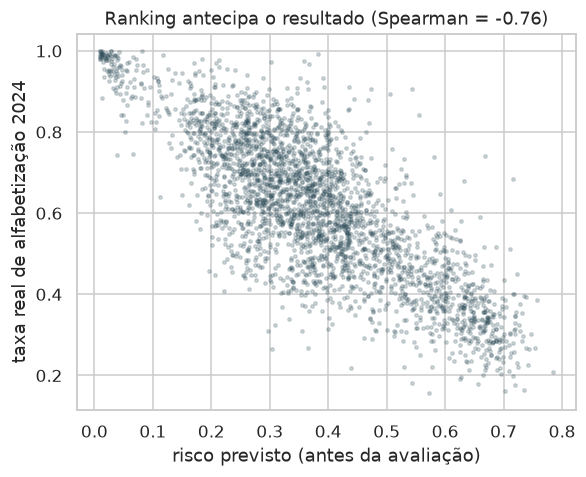

In [3]:
# Validação do ranking: o risco previsto antecipa o resultado real de 2024?
sp = risco[["risco_previsto", "taxa_real_2024"]].corr(method="spearman").iloc[0, 1]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(risco["risco_previsto"], risco["taxa_real_2024"], s=5, alpha=0.2, color="#264653")
ax.set_xlabel("risco previsto (antes da avaliação)")
ax.set_ylabel("taxa real de alfabetização 2024")
ax.set_title(f"Ranking antecipa o resultado (Spearman = {sp:.2f})")
plt.tight_layout()
plt.savefig(IMG / "estrategia_validacao_ranking.png", bbox_inches="tight")
plt.show()

### O mapa do risco previsto

Cada município pintado pela probabilidade média prevista de não alfabetização
(cinza = sem dado, caso de Roraima). O padrão territorial fala por si.

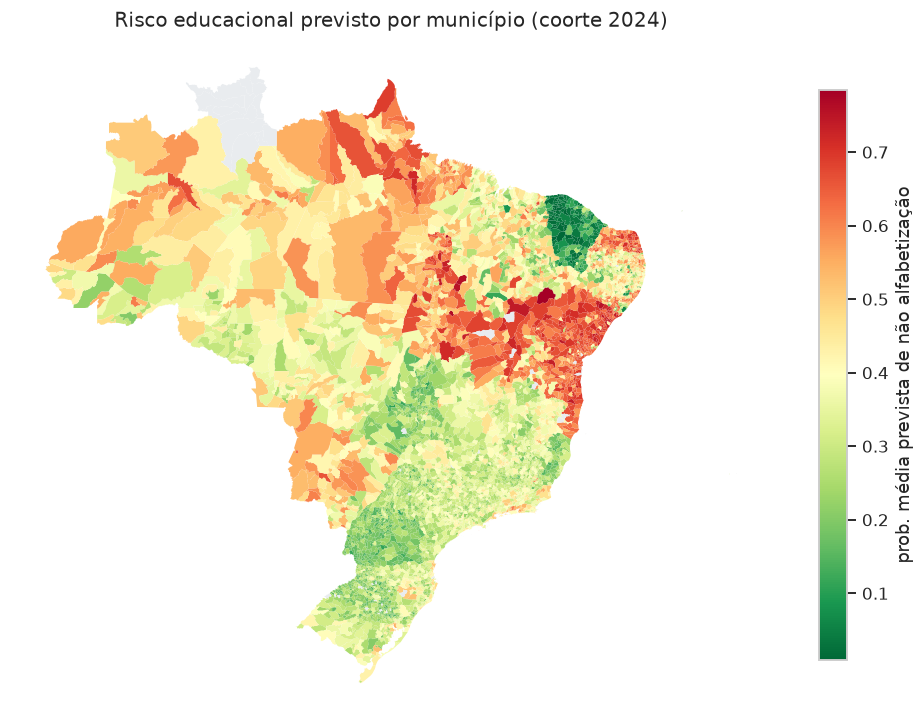

In [4]:
from src.visualization.mapa import mapa_municipal

mapa_municipal(agg.rename(columns={"risco_previsto": "risco"}), "risco",
               "Risco educacional previsto por município (coorte 2024)",
               "prob. média prevista de não alfabetização",
               IMG / "estrategia_mapa_risco.png")

## Pergunta 3: Regiões com padrões semelhantes (clustering)

KMeans sobre o **perfil municipal** (socioeconômico + educacional + resultado),
padronizado. O número de clusters é escolhido por silhueta; os perfis viram
"famílias de municípios" que pedem políticas diferentes.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

perfil_cols = ["idhm", "renda_pc", "prop_pobreza_criancas", "taxa_analfabetismo_15_mais",
               "ideb_ai_publica_anterior", "pct_internet", "pct_escolas_urbanas",
               "pib_per_capita_ano_anterior"]
mun24 = (base[base["ano"] == 2024]
         .groupby("id_municipio")
         .agg(**{c: (c, "first") for c in perfil_cols},
              taxa_2024=("alfabetizado", "mean"), regiao=("regiao", "first"))
         .reset_index())
X = SimpleImputer(strategy="median").fit_transform(mun24[perfil_cols + ["taxa_2024"]])
X = StandardScaler().fit_transform(X)

sil = {k: silhouette_score(X, KMeans(k, n_init=10, random_state=42).fit_predict(X),
                           sample_size=3000, random_state=42)
       for k in range(3, 7)}
k_otimo = max(sil, key=sil.get)
print("silhueta por k:", {k: round(v, 3) for k, v in sil.items()}, "| k escolhido:", k_otimo)
mun24["cluster"] = KMeans(k_otimo, n_init=10, random_state=42).fit_predict(X)

silhueta por k: {3: 0.344, 4: 0.277, 5: 0.211, 6: 0.221} | k escolhido: 3


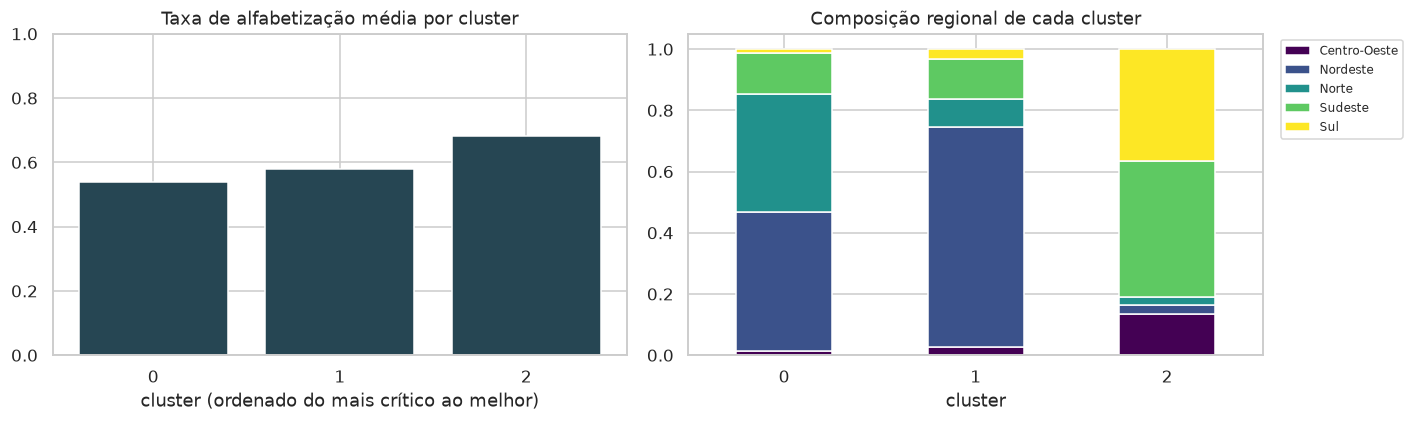

,idhm,renda_pc,prop_pobreza_criancas,taxa_analfabetismo_15_mais,ideb_ai_publica_anterior,pct_internet,pct_escolas_urbanas,pib_per_capita_ano_anterior,taxa_2024,n_municipios
cluster,,,,,,,,,,
2,0.573,263.049,59.260,23.992,4.898,0.502,0.197,20905.022,0.54,425
1,0.598,291.474,53.685,25.118,5.377,0.963,0.405,22066.855,0.58,2089
0,0.714,666.673,16.158,8.831,6.271,0.991,0.787,55763.459,0.682,3003


In [6]:
perfis = (mun24.groupby("cluster")[perfil_cols + ["taxa_2024"]].mean()
          .assign(n_municipios=mun24.groupby("cluster").size())
          .sort_values("taxa_2024"))
ordem = {c: i for i, c in enumerate(perfis.index)}
mun24["cluster_ord"] = mun24["cluster"].map(ordem)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
perfis_plot = perfis.reset_index(drop=True)
ax[0].bar(perfis_plot.index.astype(str), perfis_plot["taxa_2024"], color="#264653")
ax[0].set_title("Taxa de alfabetização média por cluster")
ax[0].set_xlabel("cluster (ordenado do mais crítico ao melhor)")
ax[0].set_ylim(0, 1)

comp = pd.crosstab(mun24["cluster_ord"], mun24["regiao"], normalize="index")
comp.plot.bar(stacked=True, ax=ax[1], colormap="viridis", rot=0)
ax[1].set_title("Composição regional de cada cluster")
ax[1].set_xlabel("cluster")
ax[1].legend(bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.savefig(IMG / "estrategia_clusters.png", bbox_inches="tight")
plt.show()
mun24.merge(nomes, on="id_municipio")[["id_municipio", "nome", "sigla_uf", "cluster_ord"]] \
     .to_csv(REP / "clusters_municipais.csv", index=False)
perfis.round(3)

## Pergunta 4: Municípios em risco de não atingir metas futuras

O Compromisso Nacional fixa metas municipais anuais até 2030. Comparamos a
**taxa prevista** pelo modelo para a coorte de 2024 (melhor estimativa
disponível da capacidade corrente da rede) com a **trajetória de metas** do
município. Município cuja performance prevista já nasce abaixo da meta do ano
seguinte é candidato prioritário a apoio.

*(Metas por ano vêm da Bronze da Fase 2: a trajetória completa 2024-2030,
não apenas o alvo final de 2030.)*

In [7]:
taxa_prevista = (agg.assign(taxa_prevista=lambda d: 1 - d["risco_previsto"])
                 [["id_municipio", "alunos", "taxa_prevista", "taxa_real_2024"]])
met = metas.groupby("id_municipio", as_index=False).agg(
    meta_2025=("meta_alfabetizacao_2025", "mean"),
    meta_2030=("meta_alfabetizacao_2030", "mean"))
compara = (taxa_prevista.merge(met, on="id_municipio")
           .merge(nomes, on="id_municipio", how="left"))
compara["gap_previsto_meta_2025"] = compara["taxa_prevista"] * 100 - compara["meta_2025"]
em_risco = compara[(compara["alunos"] >= 100) & (compara["gap_previsto_meta_2025"] < 0)]
print(f"Municípios (≥100 alunos) com performance prevista ABAIXO da meta 2025: "
      f"{len(em_risco):,} de {len(compara[compara['alunos'] >= 100]):,}")
em_risco.sort_values("gap_previsto_meta_2025").head(15)[
    ["nome", "sigla_uf", "taxa_prevista", "meta_2025", "gap_previsto_meta_2025"]].round(2)

Municípios (≥100 alunos) com performance prevista ABAIXO da meta 2025: 1,699 de 2,873


,nome,sigla_uf,taxa_prevista,meta_2025,gap_previsto_meta_2025
2067,Pindaí,BA,0.45,73.83,-28.49
1165,Santo Antônio,RN,0.43,70.80,-28.05
75,Amaturá,AM,0.41,68.27,-27.39
1215,Areia,PB,0.53,80.00,-27.33
1781,Tomar do Geru,SE,0.28,54.75,-26.51
378,Paranã,TO,0.28,54.33,-25.89
2040,Mutuípe,BA,0.40,65.42,-25.45
1362,Rio Tinto,PB,0.53,78.47,-25.36
1130,Monte Alegre,RN,0.42,65.96,-24.39
2151,Teixeira de Freitas,BA,0.37,61.04,-24.16


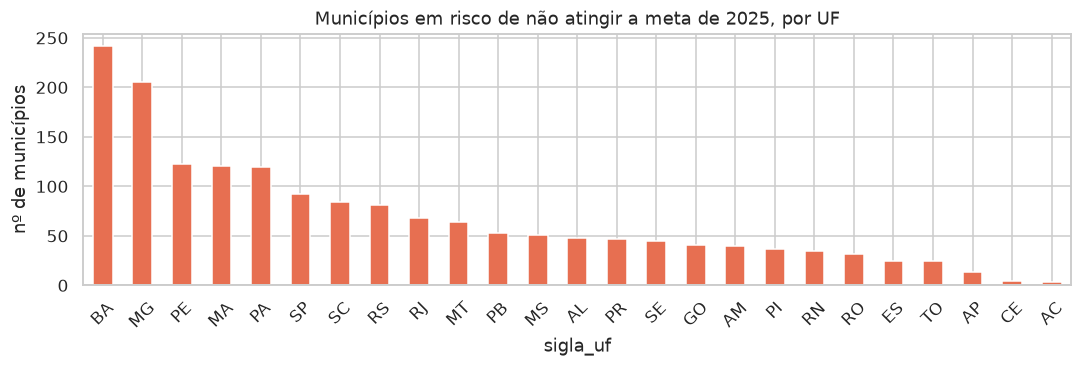

In [8]:
por_uf = (em_risco.groupby("sigla_uf").size().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(10, 3.5))
por_uf.plot.bar(ax=ax, color="#e76f51", rot=45)
ax.set_title("Municípios em risco de não atingir a meta de 2025, por UF")
ax.set_ylabel("nº de municípios")
plt.tight_layout()
plt.savefig(IMG / "estrategia_metas_uf.png", bbox_inches="tight")
plt.show()
em_risco.sort_values("gap_previsto_meta_2025").to_csv(
    REP / "municipios_risco_meta_2025.csv", index=False)

## Perguntas 1 e 5: Fatores e variáveis mais influentes

Consolidação do notebook 03 (permutation importance + SHAP), em linguagem de
gestão:

| Ordem | Fator | Leitura para política pública |
|---|---|---|
| 1º | **UF** (estado da criança) | Diferenças estaduais de política de alfabetização e regime de colaboração pesam mais que o nível socioeconômico municipal; replicar os arranjos dos estados que performam acima do esperado é a alavanca mais promissora |
| 2º | **Histórico educacional recente da rede** (nota Saeb LP e IDEB anos iniciais anteriores) | O desempenho recente da rede prediz o da criança; redes com histórico fraco precisam de apoio pedagógico estrutural, não pontual |
| 3º | **Rede (municipal × estadual) e porte** (população, tamanho da escola) | Efeito próprio menor, porém consistente |
| 4º | **Socioeconômico e infraestrutura** (IDHM, pobreza, internet, biblioteca) | Importância individual diluída porque UF e IDEB já carregam essa informação (colinearidade); a EDA mostra a correlação municipal clara; seguem relevantes para diagnóstico, não como preditores marginais |

## Síntese executiva

- O modelo **ordena risco antes da avaliação acontecer**: o ranking municipal
  previsto acompanha fortemente o resultado real de 2024.
- **Focalização:** os clusters mostram que os municípios críticos não estão
  espalhados ao acaso: concentram-se em perfis territoriais específicos
  (baixo IDHM, alta pobreza infantil, histórico educacional fraco), majoritários
  no Norte e Nordeste.
- **Metas:** parte relevante dos municípios já nasce, na previsão, abaixo da
  trajetória pactuada para 2025; a lista nominal está em
  `reports/municipios_risco_meta_2025.csv`, por UF e com o tamanho do gap.
- Uso recomendado: priorizar visitas técnicas, formação de professores
  alfabetizadores e recomposição de infraestrutura nos municípios do topo do
  ranking e dos clusters críticos, **durante** o ano letivo, sem esperar a
  próxima divulgação oficial.